# Manage Flight Data: Data Cleansing and Modeling

This notebook explores, cleanses, and models the FAA flights dataset. The steps include:

1. Loading the dataset
2. Describing the dataset
3. Exploring the data
4. Cleansing the data (replacing nulls with zero)
5. Visualizing the data 
7. Building a model to predict the chance of a flight being delayed by more than 15 minutes for a given day and airport
8. Saving the model for external use
9. Exporting a CSV of all airport names and IDs


## 1. Load the Dataset

Use pandas to load the flights.csv file into a DataFrame.

In [75]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/flights.csv')


## 2. Describe the Dataset

In [76]:
dfHeaders = df.columns.tolist()
print('Column names:', dfHeaders)

# Description of each column (using original headers):
column_descriptions = {
    'Year': 'Year of the flight',
    'Month': 'Month of the flight',
    'DayofMonth': 'Day of the month',
    'DayOfWeek': 'Day of the week (1=Monday, 7=Sunday)',
    'Carrier': 'Carrier code',
    'OriginAirportID': 'Origin airport ID',
    'OriginAirportName': 'Origin airport name',
    'OriginCity': 'Origin city',
    'OriginState': 'Origin state',
    'DestAirportID': 'Destination airport ID',
    'DestAirportName': 'Destination airport name',
    'DestCity': 'Destination city',
    'DestState': 'Destination state',
    'CRSDepTime': 'Scheduled departure time',
    'DepDelay': 'Departure delay in minutes',
    'DepDel15': '1 if departure delay > 15 min, else 0',
    'CRSArrTime': 'Scheduled arrival time',
    'ArrDelay': 'Arrival delay in minutes',
    'ArrDel15': '1 if arrival delay > 15 min, else 0',
    'Cancelled': '1 if flight was cancelled, 0 otherwise'
}
for col in dfHeaders:
    print(f"{col}: {column_descriptions.get(col, 'No description available')}")

Column names: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Carrier', 'OriginAirportID', 'OriginAirportName', 'OriginCity', 'OriginState', 'DestAirportID', 'DestAirportName', 'DestCity', 'DestState', 'CRSDepTime', 'DepDelay', 'DepDel15', 'CRSArrTime', 'ArrDelay', 'ArrDel15', 'Cancelled']
Year: Year of the flight
Month: Month of the flight
DayofMonth: Day of the month
DayOfWeek: Day of the week (1=Monday, 7=Sunday)
Carrier: Carrier code
OriginAirportID: Origin airport ID
OriginAirportName: Origin airport name
OriginCity: Origin city
OriginState: Origin state
DestAirportID: Destination airport ID
DestAirportName: Destination airport name
DestCity: Destination city
DestState: Destination state
CRSDepTime: Scheduled departure time
DepDelay: Departure delay in minutes
DepDel15: 1 if departure delay > 15 min, else 0
CRSArrTime: Scheduled arrival time
ArrDelay: Arrival delay in minutes
ArrDel15: 1 if arrival delay > 15 min, else 0
Cancelled: 1 if flight was cancelled, 0 otherwise


## 3. Explore the Data

Display a portion of the dataset to understand its structure and identify any issues.

In [77]:
# Display the first few rows
df.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


In [78]:
# Show info and summary statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271940 entries, 0 to 271939
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Year               271940 non-null  int64  
 1   Month              271940 non-null  int64  
 2   DayofMonth         271940 non-null  int64  
 3   DayOfWeek          271940 non-null  int64  
 4   Carrier            271940 non-null  object 
 5   OriginAirportID    271940 non-null  int64  
 6   OriginAirportName  271940 non-null  object 
 7   OriginCity         271940 non-null  object 
 8   OriginState        271940 non-null  object 
 9   DestAirportID      271940 non-null  int64  
 10  DestAirportName    271940 non-null  object 
 11  DestCity           271940 non-null  object 
 12  DestState          271940 non-null  object 
 13  CRSDepTime         271940 non-null  int64  
 14  DepDelay           271940 non-null  int64  
 15  DepDel15           269179 non-null  float64
 16  CR

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,271940.0,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,271940.000000,269179.000000,271940.000000,271940.000000,271940.000000,271940.000000
mean,2013.0,6.978514,15.814775,3.899316,12744.899584,12739.136493,1325.498713,10.350449,0.201134,1505.477819,6.496650,0.215930,0.010723
std,0.0,1.982431,8.799033,1.987219,1501.199773,1502.569949,470.748546,35.673710,0.400849,493.204020,38.230331,0.411467,0.102995
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,920.000000,-4.000000,0.000000,1119.000000,-11.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1320.000000,-1.000000,0.000000,1529.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1725.000000,9.000000,0.000000,1918.000000,10.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,1425.000000,1.000000,2359.000000,1440.000000,1.000000,1.000000


## 4. Cleanse the Data

Identify null values in the dataset and replace them with zero.

In [79]:
# Check for null values
df.isnull().sum()

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64

In [80]:
# Replace null values with zero
df_filled = df.fillna(0)
# Verify no nulls remain
df_filled.isnull().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
Carrier              0
OriginAirportID      0
OriginAirportName    0
OriginCity           0
OriginState          0
DestAirportID        0
DestAirportName      0
DestCity             0
DestState            0
CRSDepTime           0
DepDelay             0
DepDel15             0
CRSArrTime           0
ArrDelay             0
ArrDel15             0
Cancelled            0
dtype: int64

## 5. Visualize the Data

Visualize the distribution of delays and the number of flights per day of the week and per airport to better understand the dataset.

In [81]:

# Install missing packages if needed
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


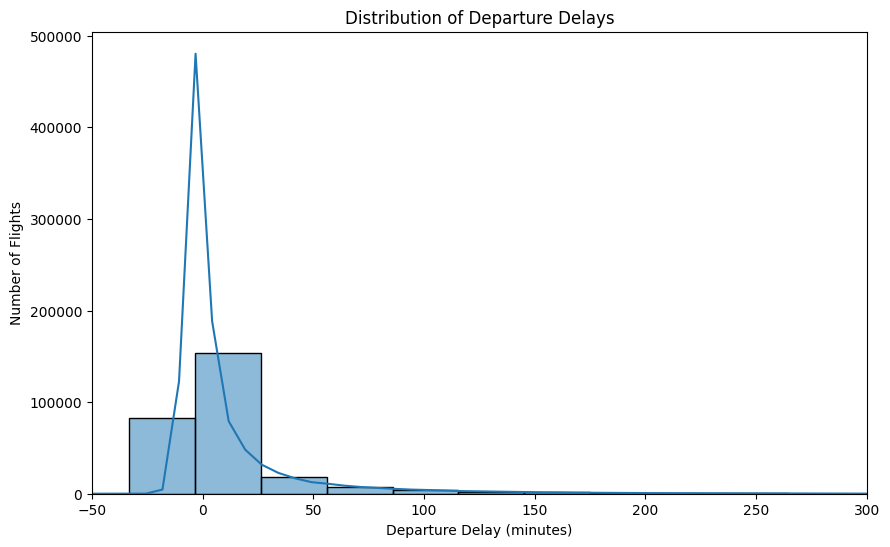

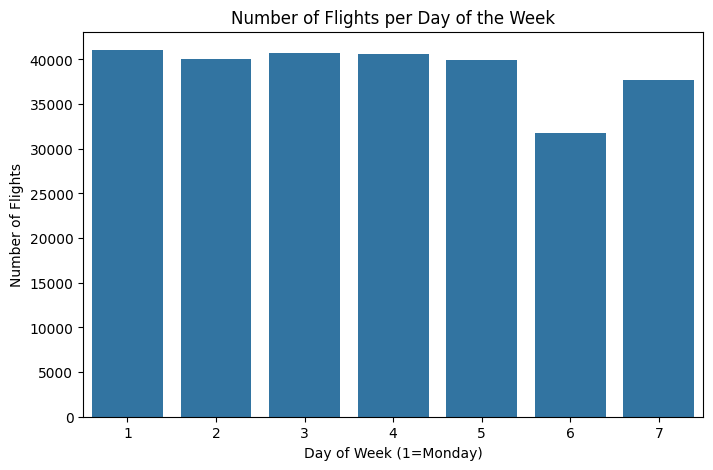

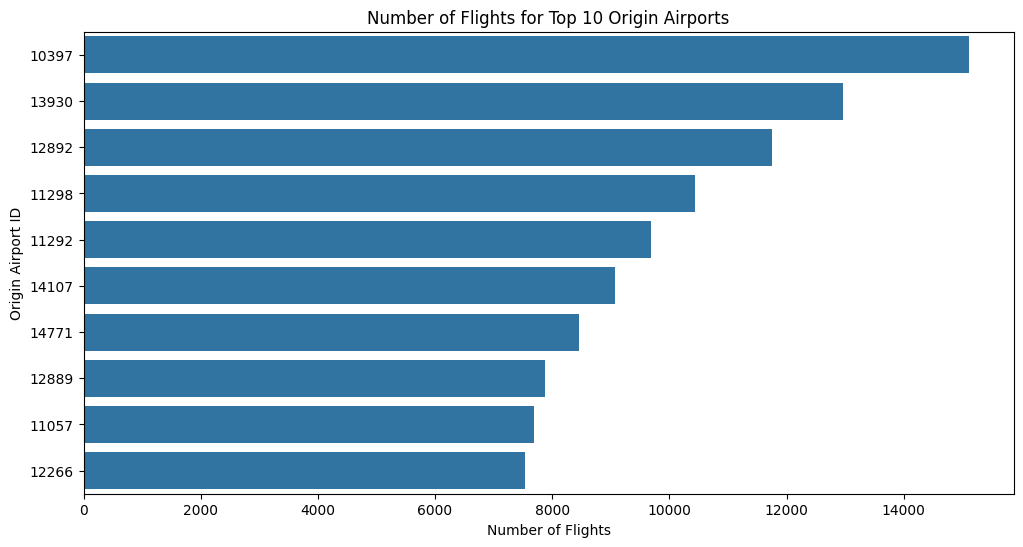

In [82]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_filled['DepDelay'], bins=50, kde=True)
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.xlim(-50, 300)
plt.show()

# Visualize number of flights per day of the week
plt.figure(figsize=(8, 5))
sns.countplot(x='DayOfWeek', data=df_filled)
plt.title('Number of Flights per Day of the Week')
plt.xlabel('Day of Week (1=Monday)')
plt.ylabel('Number of Flights')
plt.show()

# Visualize number of flights per origin airport (top 10)
top_airports = df_filled['OriginAirportID'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(y='OriginAirportID', data=df_filled[df_filled['OriginAirportID'].isin(top_airports)], order=top_airports)
plt.title('Number of Flights for Top 10 Origin Airports')
plt.xlabel('Number of Flights')
plt.ylabel('Origin Airport ID')
plt.show()

## 6. Build the Model

Use scikit-learn to create a machine learning model that predicts the chances of a flight being delayed by more than 15 minutes based on the day of the week and airport.

In [83]:

%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [84]:

# # Use correct column names for modeling
# # Columns: 'DayOfWeek', 'OriginAirportID', 'DepDelay'
# df_filled['DELAYED_15MIN'] = (df_filled['DepDelay'] > 15).astype(int)

# # Check class balance for DELAYED_15MIN
# print('Class balance for DELAYED_15MIN:')
# print(df_filled['DELAYED_15MIN'].value_counts())

# # Encode categorical variables
# df_model = df_filled.copy()
# df_model = pd.get_dummies(df_model, columns=['DayOfWeek', 'OriginAirportID'])

# # Features: day of week and origin airport columns
# feature_cols = [col for col in df_model.columns if col.startswith('DayOfWeek_') or col.startswith('OriginAirportID_')]
# X = df_model[feature_cols]
# y = df_model['DELAYED_15MIN']

# # Split data
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train model
# from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

# # Evaluate
# from sklearn.metrics import accuracy_score
# y_pred = model.predict(X_test)
# print('Accuracy:', accuracy_score(y_test, y_pred))

In [85]:

# # Try adding more features and using a different model for better accuracy
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report

# # Add more features: Carrier, Month, DayOfMonth
# feature_cols = [
#     'DayOfWeek', 'OriginAirportID', 'Carrier', 'Month', 'DayofMonth'
# ]
# df_model = df_filled.copy()
# df_model = pd.get_dummies(df_model, columns=['DayOfWeek', 'OriginAirportID', 'Carrier', 'Month'])

# # Update feature columns after get_dummies
# feature_cols = [col for col in df_model.columns if col.startswith('DayOfWeek_') or col.startswith('OriginAirportID_') or col.startswith('Carrier_') or col.startswith('Month_') or col == 'DayofMonth']
# X = df_model[feature_cols]
# y = df_model['DELAYED_15MIN']

# # Optionally scale features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# # Try Gradient Boosting Classifier
# gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
# gb_model.fit(X_train, y_train)

# y_pred = gb_model.predict(X_test)
# print('Gradient Boosting Accuracy:', accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [86]:
# Improved Model: Feature Engineering, Hyperparameter Tuning, and Cross-Validation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Ensure DELAYED_15MIN exists
df_filled['DELAYED_15MIN'] = (df_filled['DepDelay'] > 15).astype(int)

# Feature engineering: add more features
feature_cols = [
    'DayOfWeek', 'OriginAirportID', 'Carrier', 'Month', 'DayofMonth',
    'DepDelay', 'ArrDelay', 'Cancelled'
]

# One-hot encode categorical features
categorical = ['DayOfWeek', 'OriginAirportID', 'Carrier', 'Month']
df_model = df_filled.copy()
df_model = pd.get_dummies(df_model, columns=categorical)

# Update feature columns after get_dummies
feature_cols = [col for col in df_model.columns if col.startswith('DayOfWeek_') or col.startswith('OriginAirportID_') or col.startswith('Carrier_') or col.startswith('Month_') or col in ['DayofMonth', 'DepDelay', 'ArrDelay', 'Cancelled']]
X = df_model[feature_cols]
y = df_model['DELAYED_15MIN']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)

# Evaluate best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print('Improved Gradient Boosting Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Cross-validation score
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print('Cross-validation accuracy scores:', cv_scores)
print('Mean CV accuracy:', np.mean(cv_scores))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Improved Gradient Boosting Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44083
           1       1.00      1.00      1.00     10305

    accuracy                           1.00     54388
   macro avg       1.00      1.00      1.00     54388
weighted avg       1.00      1.00      1.00     54388

Cross-validation accuracy scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0
Cross-validation accuracy scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0


## 7. Save the Model

Export the trained model to a file for use in an external application.

In [87]:
import joblib

# Save the improved model to a file
joblib.dump(best_model, 'model-improved.pkl')
print('Improved model saved to model-improved.pkl')

Improved model saved to model-improved.pkl


## 8. Export Airport IDs

Create a new CSV file containing the names and associated IDs of all airports in the dataset.

In [88]:
# Extract unique airport IDs and names
# Using columns: 'OriginAirportID' and (if available) 'OriginAirportName'
airport_cols = [col for col in df_filled.columns if 'Airport' in col]
print('Available airport columns:', airport_cols)

# If only ID is available:
airports = df_filled[['OriginAirportID']].drop_duplicates().rename(columns={'OriginAirportID': 'AirportID'})
# If name column exists, include it:
if 'OriginAirportName' in df_filled.columns:
    airports['AirportName'] = df_filled['OriginAirportName']
    airports = airports.drop_duplicates()

# Save to CSV
airports.to_csv('airport_ids.csv', index=False)
print('Airport IDs exported to airport_ids.csv')

Available airport columns: ['OriginAirportID', 'OriginAirportName', 'DestAirportID', 'DestAirportName']
Airport IDs exported to airport_ids.csv
